In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
from scipy.stats import median_abs_deviation

In [2]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'figure.titlesize': 16,
    'axes.titlesize': 16,
    'axes.labelsize': 12,

    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',

    'legend.frameon': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.axisbelow': True
})

In [3]:
def format_plot(ax, title, xlabel, ylabel, horizontal=False):

    ax.set_title(title, pad=20)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if horizontal:
        ax.grid(axis='x', linestyle='--', alpha=0.5)
        ax.grid(axis='y', visible=False)
    else:
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.grid(axis='x', visible=False)

In [4]:
def get_clean_mask(data, threshold=3.5):
    """
    Apply Iglewicz and Hoaglin's robust outlier detection.
    Returns: Boolean mask (True = Valid, False = Outlier)
    """
    median = np.median(data)
    mad = median_abs_deviation(data, scale='normal')
    modified_z_score = 0.6745 * (data - median) / mad
    return modified_z_score.abs() < threshold

def get_limits(data):
    """
    Calculates a SYMMETRIC limit centered on 0.
    1. Takes the Absolute Value of the errors.
    2. Finds the Nth percentile of those absolute values.
    3. Returns [-Limit, +Limit].
    """
    abs_data = data.abs()
    limit = np.percentile(abs_data, 99)
    return limit

In [5]:
def _Bland_Altman_comparison(dataframe, col_mean_raw, col_diff_raw, col_mean_fixed, col_diff_fixed, col_fix_bool):
    """
    Final Output:
    - Global Y-Limits (Honest Comparison).
    - Shaded Confidence Zones (Visual Clarity).
    - Logic: Green = 'Repaired' (Algorithm touched it).
    - Labels: 'Repaired Data', 'Difference (Method - Ref)', 'Mean (Repaired + Ref) / 2'.
    - Annotations: Top 5 Outliers labeled with IDs.
    """

    # Create local copy to avoid modifying original df
    df = dataframe.copy()

    # --- 1. GLOBAL LIMITS ---
    # Calculate limits from BOTH datasets so the Y-axis is identical
    y_all = pd.concat([df[col_diff_raw], df[col_diff_fixed]])
    y_max = y_all.max()
    y_min = y_all.min()
    y_range = y_max - y_min
    # Add 12% padding for labels
    y_lims = (y_min - y_range * 0.12, y_max + y_range * 0.12)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

    # Colors
    c_valid  = '#95a5a6' # Concrete Grey
    c_bad    = '#e74c3c' # Alizarin Red
    c_good   = '#27ae60' # Nephritis Green

    # Helper for Stats Box
    def add_stats_box(ax, data, loc='lower right'):
        mean = data.mean()
        sd = data.std()
        loa_up = mean + 1.96 * sd
        loa_low = mean - 1.96 * sd

        stats_text = (f"Bias: {mean:.2f}\n"
                      f"SD: {sd:.2f}\n"
                      f"LOA: [{loa_low:.2f}, {loa_up:.2f}]")
        at = AnchoredText(stats_text, prop=dict(size=10, fontfamily='monospace'),
                          frameon=True, loc=loc)
        at.patch.set_boxstyle("round,pad=0.2,rounding_size=0.2")
        at.patch.set_edgecolor('#dcdcdc')
        at.patch.set_alpha(0.95)
        ax.add_artist(at)
        return mean, loa_up, loa_low

    # ==========================================
    # PANEL A: RAW DATA
    # ==========================================
    mean_a, loa_up_a, loa_low_a = add_stats_box(ax1, df[col_diff_raw])

    # Identify Raw Outliers
    mask_outlier = (df[col_diff_raw] > loa_up_a) | (df[col_diff_raw] < loa_low_a)

    # Shaded Region (Safe Zone)
    ax1.axhspan(loa_low_a, loa_up_a, color=c_good, alpha=0.05, zorder=0)

    # Plot Points
    ax1.scatter(df.loc[~mask_outlier, col_mean_raw], df.loc[~mask_outlier, col_diff_raw],
                c=c_valid, alpha=0.5, s=40, label='Valid', zorder=1)
    # Slight transparency on red dots in Panel A to match Panel B's aesthetic
    ax1.scatter(df.loc[mask_outlier, col_mean_raw], df.loc[mask_outlier, col_diff_raw],
                c=c_bad, alpha=0.9, s=60, label='Outlier', zorder=2, edgecolors='white', linewidth=0.5)

    # Reference Lines
    ax1.axhline(mean_a, color='black', lw=1.5, zorder=3)
    ax1.axhline(loa_up_a, color='black', ls=':', lw=1.2, zorder=3)
    ax1.axhline(loa_low_a, color='black', ls=':', lw=1.2, zorder=3)

    # Labels Panel A
    ax1.set_title("A. Raw Data", pad=15)
    ax1.set_xlabel("Mean (Raw + Ref) / 2")
    ax1.set_ylabel("Difference (Method - Ref)")
    ax1.set_ylim(y_lims) # Force Global Scale

    # ==========================================
    # PANEL B: REPAIRED DATA
    # ==========================================
    mean_b, loa_up_b, loa_low_b = add_stats_box(ax2, df[col_diff_fixed])

    # --- LOGIC ---
    cond_outlier = (df[col_diff_fixed] > loa_up_b) | (df[col_diff_fixed] < loa_low_b)

    # Priority: 1. Algorithm Touched -> Green, 2. Else -> Red/Gray
    conditions = [
        df[col_fix_bool].astype(bool),
        cond_outlier,
    ]
    choices = ['Repaired', 'Unresolved']

    df['Status'] = np.select(conditions, choices, default='Valid')

    # --- PLOTTING ---

    # Layer 1: Valid Background (Pushed back)
    ax2.scatter(df.loc[df['Status']=='Valid', col_mean_fixed],
                df.loc[df['Status']=='Valid', col_diff_fixed],
                c=c_valid, alpha=0.2, s=40, zorder=1)

    # Layer 2: Action Data
    palette = {'Repaired': c_good, 'Unresolved': c_bad}
    markers = {'Repaired': 'X',    'Unresolved': 'P'}

    df_action = df[df['Status'].isin(palette.keys())].copy()

    if not df_action.empty:
        sns.scatterplot(data=df_action, x=col_mean_fixed, y=col_diff_fixed,
                        hue='Status', style='Status',
                        palette=palette, markers=markers,
                        s=100, edgecolor='white', linewidth=0.5,
                        ax=ax2, zorder=3)

    # Shaded Region
    ax2.axhspan(loa_low_b, loa_up_b, color=c_good, alpha=0.1, zorder=0)

    # Reference Lines
    ax2.axhline(mean_b, color='black', lw=1.5, zorder=3)
    ax2.axhline(loa_up_b, color=c_good, ls='--', lw=1.5, zorder=3)
    ax2.axhline(loa_low_b, color=c_good, ls='--', lw=1.5, zorder=3)

    # --- ANNOTATIONS (ENABLED) ---
    # Label top 5 worst Unresolved/Repaired points if they are outliers
    # We focus on 'Unresolved' first as they are critical errors
    df_bad = df[df['Status'] == 'Unresolved']

    if not df_bad.empty:
        top_fails = df_bad.reindex(
            df_bad[col_diff_fixed].abs().sort_values(ascending=False).index
        ).head(5)

        for idx, row in top_fails.iterrows():
            ax2.annotate(f"{idx}", (row[col_mean_fixed], row[col_diff_fixed]),
                         xytext=(0, 7), textcoords='offset points', ha='center',
                         fontsize=9, fontweight='bold', color=c_bad,
                         bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.7, ec="none"))

    # Labels Panel B
    ax2.set_title("B. Repaired Data", pad=15)
    ax2.set_xlabel("Mean (Repaired + Ref) / 2") # Matching Title

    # Clean Legend
    if ax2.get_legend():
        ax2.legend(title='', loc='upper right', framealpha=0.95)

    plt.tight_layout()
    plt.show()

In [6]:
filePath = '../Dataset/UCI_Gallstone_Dataset.csv'
df = pd.read_csv(filePath)

In [7]:
df_bioimpedance = df[[
    'Weight',
    'Total Body Water (TBW)',         # Measured in kg
    'Extracellular Water (ECW)',      # Measured in kg
    'Intracellular Water (ICW)',      # Measured in kg
    'Extracellular Fluid/Total Body Water (ECF/TBW)', # Derived Fluid Ratio
    'Total Body Fat Ratio (TBFR) (%)',# Percentage of total mass
    'Lean Mass (LM) (%)',             # Percentage of fat-free mass
    'Body Protein Content (Protein) (%)', # Protein composition percentage
    'Visceral Fat Rating (VFR)',      # Corresponds to "Visceral Adiposity Index" in text [cite: 61]
    'Bone Mass (BM)',                 # Measured in kg
    'Muscle Mass (MM)',               # Measured in kg
    'Obesity (%)',                    # Degree of obesity percentage
    'Total Fat Content (TFC)',        # Measured in kg
    'Visceral Fat Area (VFA)',        # Measured in kg
    'Visceral Muscle Area (VMA) (Kg)' # Measured in kg
]].copy()

In [8]:
# Track A: Physics (Summation) | TBW - (ECW + ICW)
col_TBW_calc_sum = 'TBW_calc_sum'
df_bioimpedance[col_TBW_calc_sum] = df_bioimpedance['Extracellular Water (ECW)'] + df_bioimpedance['Intracellular Water (ICW)']

col_TBW_disc_sum = 'TBW_disc_sum'
df_bioimpedance[col_TBW_disc_sum] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance[col_TBW_calc_sum]

# Track B: Logic (Ratio) | TBW - ECW / (Ratio/100)
col_TBW_calc_ratio = 'TBW_calc_ratio'
df_bioimpedance[col_TBW_calc_ratio] = df_bioimpedance['Extracellular Water (ECW)'] / (df_bioimpedance['Extracellular Fluid/Total Body Water (ECF/TBW)'] / 100)

col_TBW_disc_ratio = 'TBW_disc_ratio'
df_bioimpedance[col_TBW_disc_ratio] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance[col_TBW_calc_ratio]

# Track C: 4-Component Model | TBW - (Weight - Fat - Bone - Protein - 0.013*Weight)
epsilon_4C = df_bioimpedance['Weight']*0.013

col_TFC_calc_ratio = 'TFC_calc_ratio'
df_bioimpedance[col_TFC_calc_ratio] = (df_bioimpedance['Weight'] * (df_bioimpedance['Total Body Fat Ratio (TBFR) (%)'] / 100))

col_TPC_calc_ratio = 'TPC_calc_ratio'
df_bioimpedance[col_TPC_calc_ratio] = (df_bioimpedance['Weight'] * (df_bioimpedance['Body Protein Content (Protein) (%)'] / 100))

col_TBW_calc_4C = 'TBW_calc_4C'
df_bioimpedance[col_TBW_calc_4C] = df_bioimpedance['Weight'] - df_bioimpedance[col_TFC_calc_ratio] - df_bioimpedance['Bone Mass (BM)'] - df_bioimpedance[
    col_TPC_calc_ratio] - epsilon_4C

col_TBW_disc_4C = 'TBW_disc_4C'
df_bioimpedance[col_TBW_disc_4C] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance[col_TBW_calc_4C]

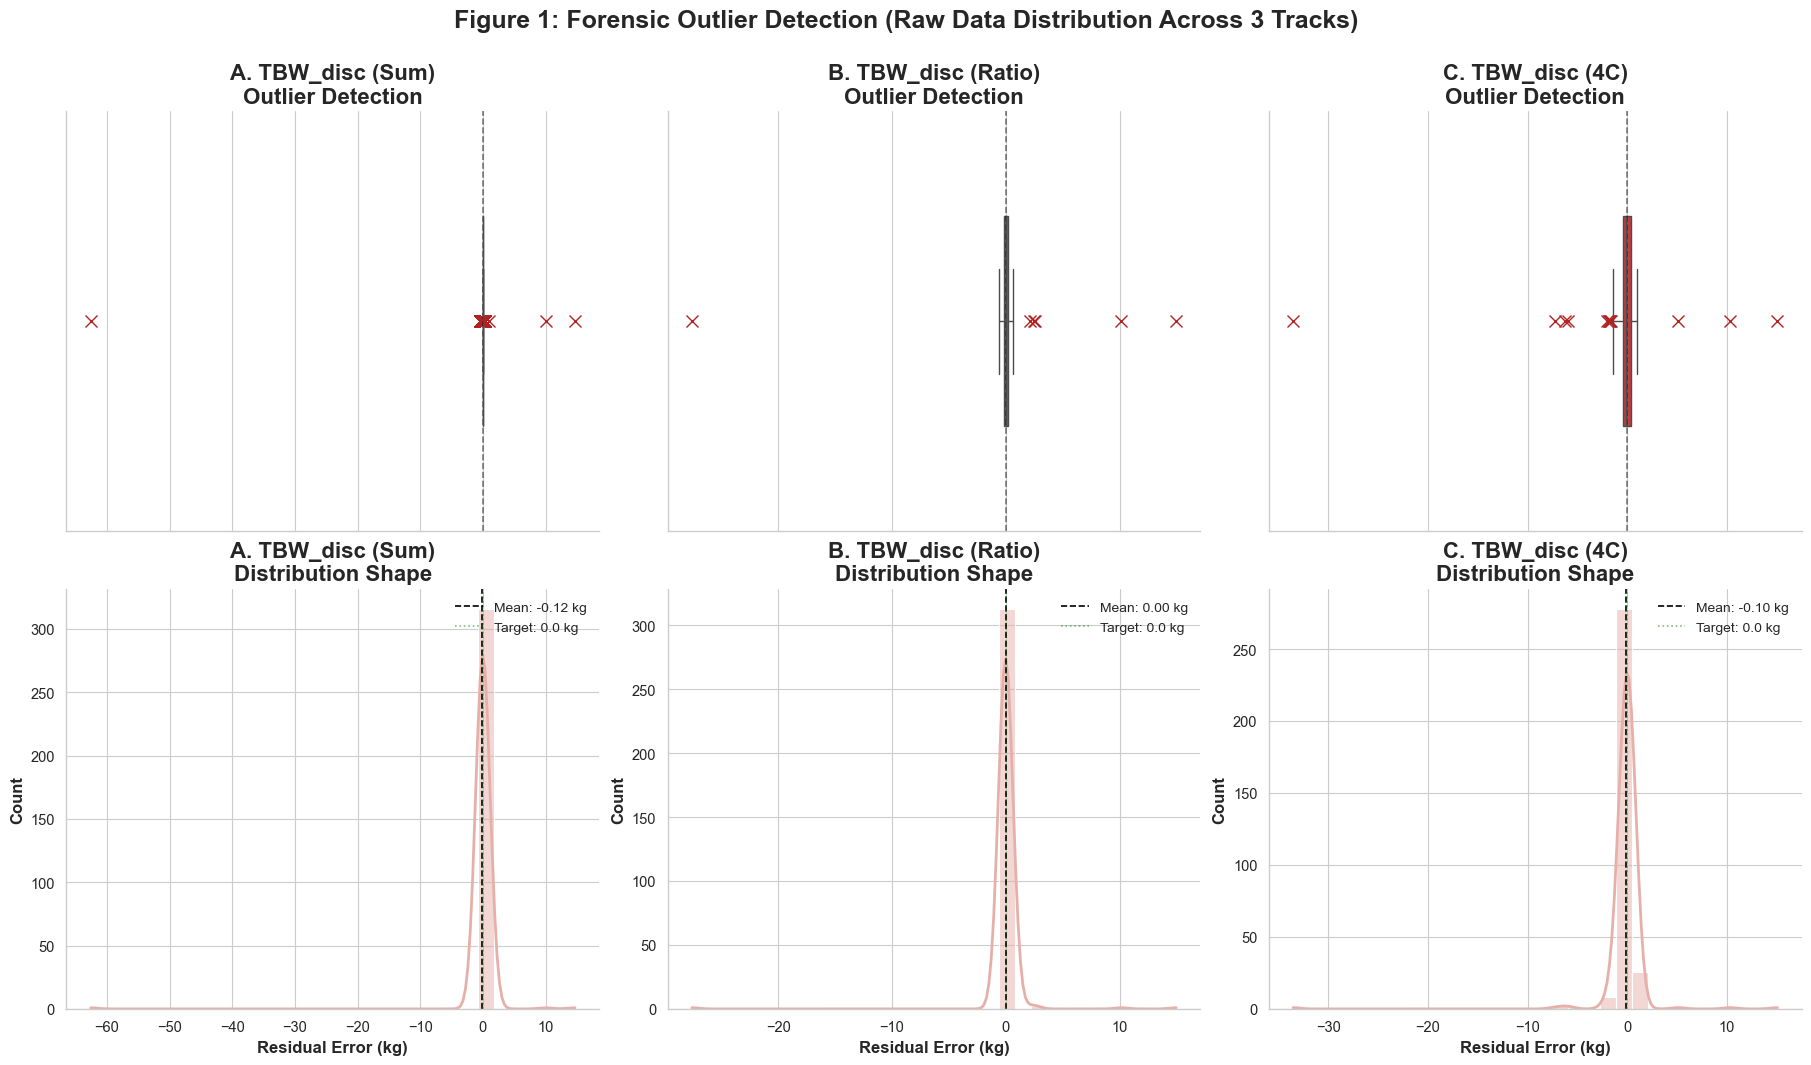

In [9]:
#(Figure 1: Distribution Analysis) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True, sharex='col')

tracks = [
    ('A. TBW_disc (Sum)'    , col_TBW_disc_sum),
    ('B. TBW_disc (Ratio)'  , col_TBW_disc_ratio),
    ('C. TBW_disc (4C)'     , col_TBW_disc_4C)
]

for i, (title, col) in enumerate(tracks):
    data = df_bioimpedance[col]

    # Upper Plot: Boxplot
    sns.boxplot(x=data, ax=axes[0, i], color='tab:red', width=0.5,
                flierprops={"marker": "x", "markeredgecolor": "firebrick", "markersize": 8})
    axes[0, i].set_title(f"{title}\nOutlier Detection", fontweight='bold')
    axes[0, i].axvline(0, color='black', linestyle='--', alpha=0.5)

    # Lower Plot: Histogram
    # Safety Check: Prevent crash on empty columns
    if not data.isnull().all():
        sns.histplot(x=data, ax=axes[1, i], color='#E6B0AA', bins=30, kde=True,
                     line_kws={'linewidth': 2, 'color': 'firebrick'})

        mean_val = data.mean()
        axes[1, i].axvline(mean_val, color='black', linestyle='--', label=f'Mean: {mean_val:.2f} kg')
        axes[1, i].axvline(0, color='green', linestyle=':', alpha=0.5, label='Target: 0.0 kg')

    axes[1, i].set_title(f"{title}\nDistribution Shape", fontweight='bold')
    axes[1, i].set_xlabel("Residual Error (kg)")
    axes[1, i].legend(loc='upper right', fontsize=10)

plt.suptitle("Figure 1: Forensic Outlier Detection (Raw Data Distribution Across 3 Tracks)",
             y=1.05, fontsize=18, fontweight='bold')
plt.show()

In [10]:
TBW_disc_sum_lim_val = get_limits(df_bioimpedance[col_TBW_disc_sum])
TBW_disc_ratio_lim_val = get_limits(df_bioimpedance[col_TBW_disc_ratio])

# 2. GENERATE MASKS (Using the new symmetric limits)
TBW_disc_fit_sum_lim = (df_bioimpedance[col_TBW_disc_sum].abs() < TBW_disc_sum_lim_val)
TBW_disc_fit_ratio_lim = (df_bioimpedance[col_TBW_disc_ratio].abs() < TBW_disc_ratio_lim_val)

TBW_disc_fail_both_lim = ~TBW_disc_fit_sum_lim & ~TBW_disc_fit_ratio_lim
TBW_disc_fail_ratio_lim = TBW_disc_fit_sum_lim & ~TBW_disc_fit_ratio_lim
TBW_disc_fail_sum_lim = ~TBW_disc_fit_sum_lim & TBW_disc_fit_ratio_lim
TBW_disc_fit_both_lim = TBW_disc_fit_sum_lim & TBW_disc_fit_ratio_lim

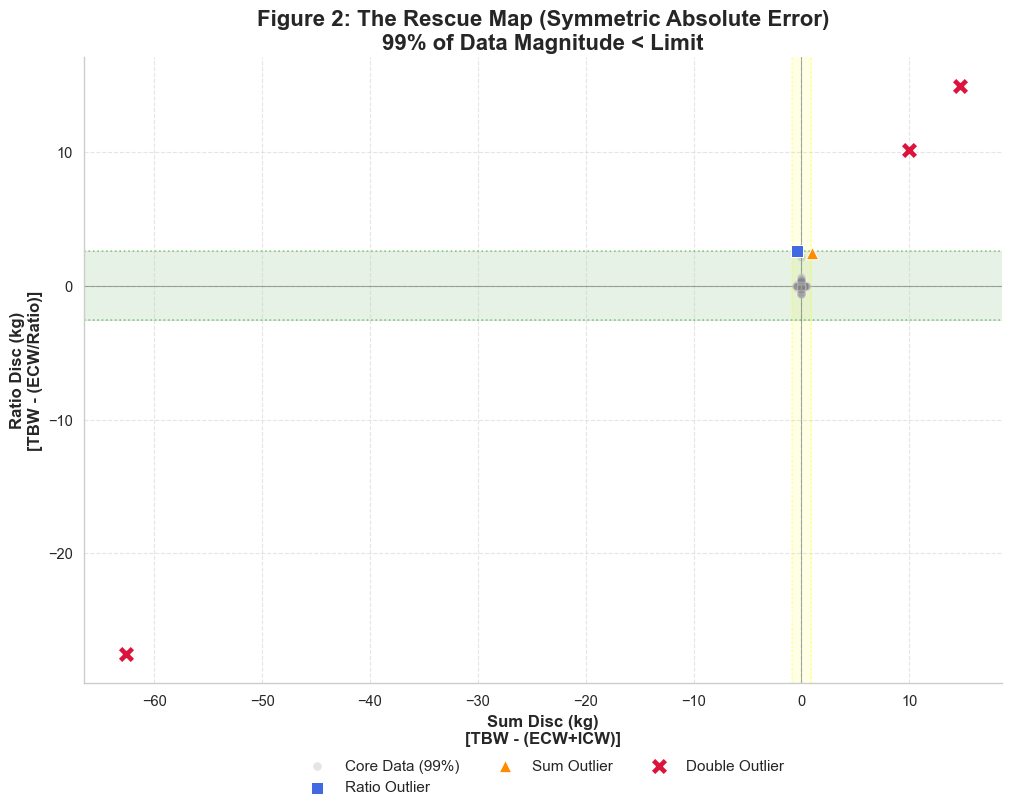

In [11]:
# --- 2. Figure 2: The Rescue Map (Symmetric Absolute Percentiles) ---
fig2, ax2 = plt.subplots(figsize=(10, 8), constrained_layout=True)

# A. DRAW THE ZONES (Perfectly Centered Cross)
ax2.axvspan(-TBW_disc_sum_lim_val, TBW_disc_sum_lim_val, color='yellow', alpha=0.1, zorder=0)
ax2.axhspan(-TBW_disc_ratio_lim_val, TBW_disc_ratio_lim_val, color='green', alpha=0.1, zorder=0)

# Dotted boundaries for visibility
ax2.axvline(-TBW_disc_sum_lim_val, color='yellow', linestyle=':', alpha=0.4)
ax2.axvline(TBW_disc_sum_lim_val, color='yellow', linestyle=':', alpha=0.4)
ax2.axhline(-TBW_disc_ratio_lim_val, color='green', linestyle=':', alpha=0.4)
ax2.axhline( TBW_disc_ratio_lim_val, color='green', linestyle=':', alpha=0.4)

# Center lines
ax2.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.3, zorder=1)
ax2.axvline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.3, zorder=1)

# B. SCATTER PLOTS
sns.scatterplot(data=df_bioimpedance[TBW_disc_fit_both_lim], x=col_TBW_disc_sum, y=col_TBW_disc_ratio,
                color='gray', alpha=0.2, s=40, label=f'Core Data (99%)', ax=ax2, zorder=2)

sns.scatterplot(data=df_bioimpedance[TBW_disc_fail_ratio_lim], x=col_TBW_disc_sum, y=col_TBW_disc_ratio,
                color='royalblue', s=80, marker='s', label='Ratio Outlier', ax=ax2, zorder=3)

sns.scatterplot(data=df_bioimpedance[TBW_disc_fail_sum_lim], x=col_TBW_disc_sum, y=col_TBW_disc_ratio,
                color='darkorange', s=80, marker='^', label='Sum Outlier', ax=ax2, zorder=4)

sns.scatterplot(data=df_bioimpedance[TBW_disc_fail_both_lim], x=col_TBW_disc_sum, y=col_TBW_disc_ratio,
                color='crimson', s=150, marker='X', label='Double Outlier', ax=ax2, zorder=5)

ax2.set_title(f"Figure 2: The Rescue Map (Symmetric Absolute Error)\n99% of Data Magnitude < Limit",
              fontweight='bold', fontsize=16)
ax2.set_xlabel("Sum Disc (kg)\n[TBW - (ECW+ICW)]", fontweight='bold')
ax2.set_ylabel("Ratio Disc (kg)\n[TBW - (ECW/Ratio)]", fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5, zorder=0)

ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
           ncol=3, frameon=False, fontsize=11)

plt.show()

In [12]:
# Fixing TBW column
col_TBW_fixed = 'TBW_fixed'
df_bioimpedance[col_TBW_fixed] = df_bioimpedance['Total Body Water (TBW)']
col_TBW_fix_status = 'TBW_fixed_status'
df_bioimpedance[col_TBW_fix_status] = False

# CASE 1: Ratio Failed -> Use Sum
df_bioimpedance.loc[TBW_disc_fail_ratio_lim, col_TBW_fixed] = df_bioimpedance.loc[TBW_disc_fail_ratio_lim, col_TBW_calc_sum]
df_bioimpedance.loc[TBW_disc_fail_ratio_lim, col_TBW_fix_status] = True

# CASE 2: Sum Failed -> Use Ratio
df_bioimpedance.loc[TBW_disc_fail_sum_lim, col_TBW_fixed] = df_bioimpedance.loc[TBW_disc_fail_sum_lim, col_TBW_calc_ratio]
df_bioimpedance.loc[TBW_disc_fail_sum_lim, col_TBW_fix_status] = True

# === CASE 3: Both Failed -> Fallback to Ratio ===
df_bioimpedance.loc[TBW_disc_fail_both_lim, col_TBW_fixed] = df_bioimpedance.loc[TBW_disc_fail_both_lim, col_TBW_calc_ratio]
df_bioimpedance.loc[TBW_disc_fail_both_lim, col_TBW_fix_status] = True

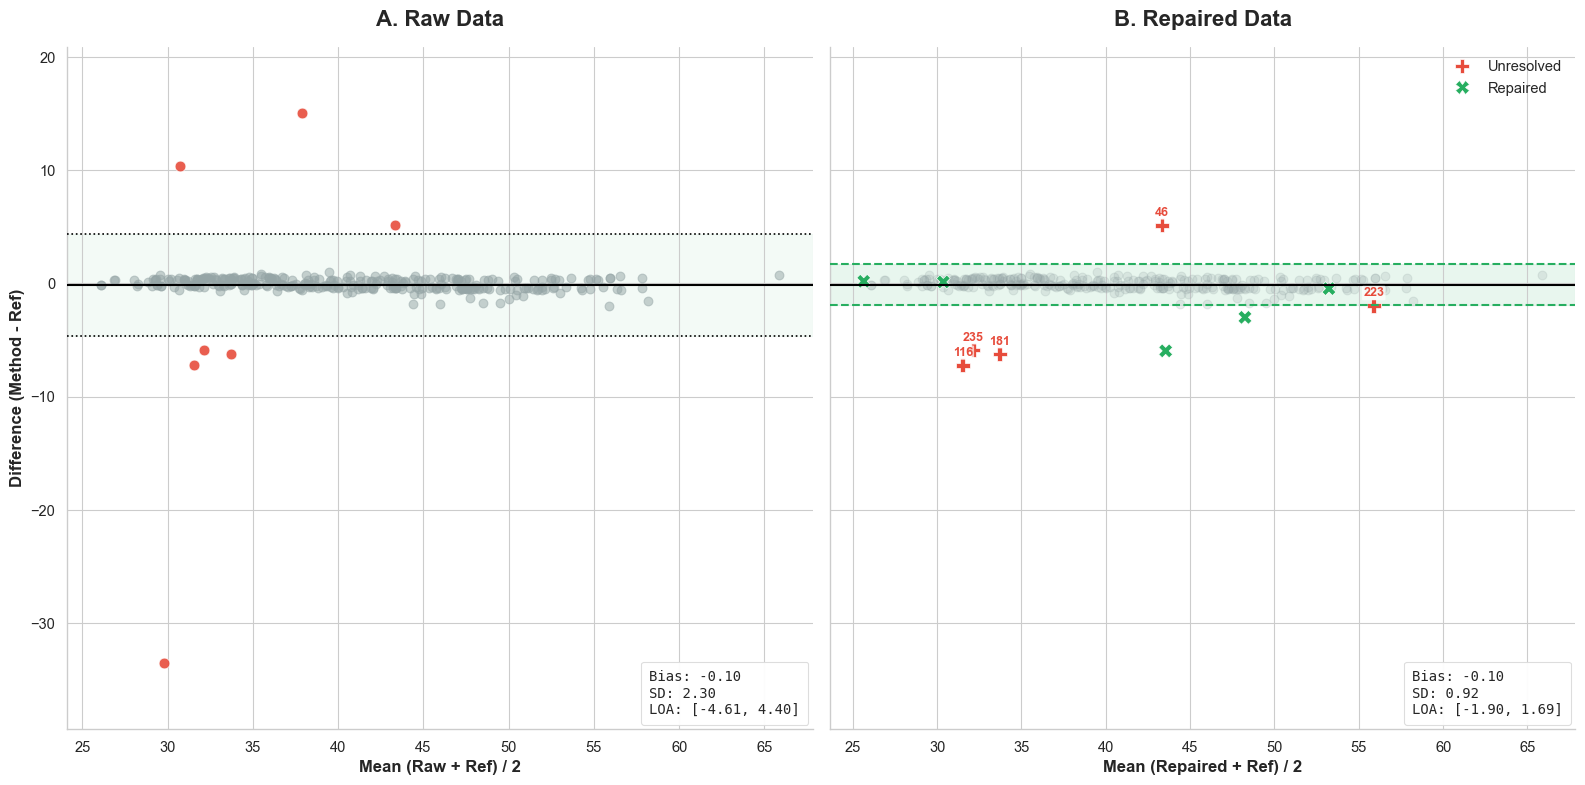

In [13]:
col_TBW_mean_raw = 'TBW_mean_raw'
df_bioimpedance[col_TBW_mean_raw] = (df_bioimpedance['Total Body Water (TBW)'] + df_bioimpedance[col_TBW_calc_4C]) / 2
col_TBW_diff_raw = 'TBW_diff_raw'
df_bioimpedance[col_TBW_diff_raw] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance[col_TBW_calc_4C]
col_TBW_mean_fixed = 'TBW_mean_fixed'
df_bioimpedance[col_TBW_mean_fixed] = (df_bioimpedance[col_TBW_fixed] + df_bioimpedance[col_TBW_calc_4C]) / 2
col_TBW_diff_fixed = 'TBW_diff_fixed'
df_bioimpedance[col_TBW_diff_fixed] = df_bioimpedance[col_TBW_fixed] - df_bioimpedance[col_TBW_calc_4C]

_Bland_Altman_comparison(df_bioimpedance,col_TBW_mean_raw,col_TBW_diff_raw,col_TBW_mean_fixed,col_TBW_diff_fixed,col_TBW_fix_status)

In [14]:
col_TFC_calc_lean = 'TFC_calc_lean'
df_bioimpedance[col_TFC_calc_lean] = df_bioimpedance['Weight'] - (df_bioimpedance['Weight'] * df_bioimpedance['Lean Mass (LM) (%)'] / 100)

col_TFC_disc_lean = 'TFC_disc_lean'
df_bioimpedance[col_TFC_disc_lean] = df_bioimpedance['Total Fat Content (TFC)'] - df_bioimpedance[col_TFC_calc_lean]

col_TFC_calc_ratio = 'TFC_calc_ratio'
df_bioimpedance[col_TFC_calc_ratio] = (df_bioimpedance['Weight'] * (df_bioimpedance['Total Body Fat Ratio (TBFR) (%)'] / 100))

col_TFC_disc_ratio = 'TFC_disc_ratio'
df_bioimpedance[col_TFC_disc_ratio] = df_bioimpedance['Total Fat Content (TFC)'] - df_bioimpedance[col_TFC_calc_ratio]

col_TFC_calc_sumOfRatio = 'TFC_calc_sumOfRatio'
df_bioimpedance[col_TFC_calc_sumOfRatio] = df_bioimpedance['Lean Mass (LM) (%)'] + df_bioimpedance['Total Body Fat Ratio (TBFR) (%)']

col_TFC_disc_sumOfRatio = 'TFC_disc_sumOfRatio'
df_bioimpedance[col_TFC_disc_sumOfRatio] = 100 - df_bioimpedance[col_TFC_calc_sumOfRatio]

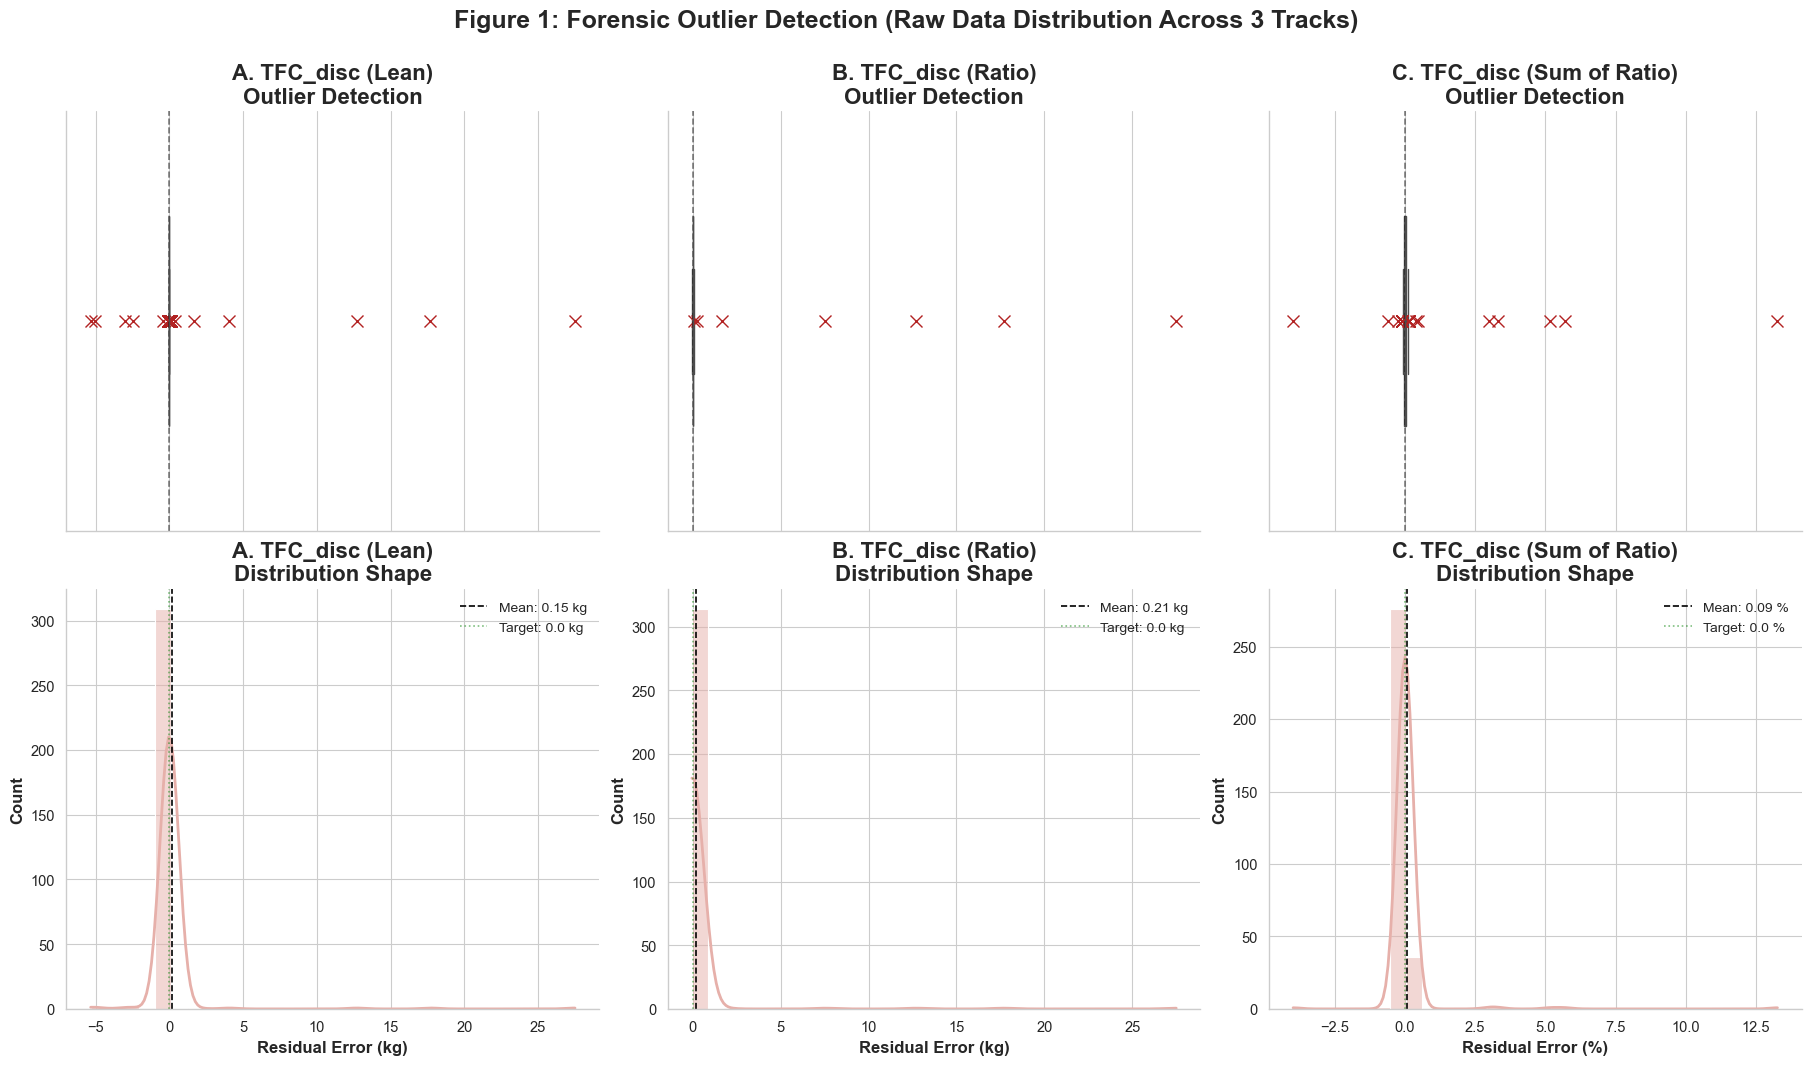

In [15]:
#(Figure 1: Distribution Analysis) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True, sharex='col')

tracks = [
    ('A. TFC_disc (Lean)'   , col_TFC_disc_lean),
    ('B. TFC_disc (Ratio)'  , col_TFC_disc_ratio),
    ('C. TFC_disc (Sum of Ratio)'     , col_TFC_disc_sumOfRatio)
]

for i, (title, col) in enumerate(tracks):
    data = df_bioimpedance[col]

    # --- DYNAMIC UNIT LOGIC ---
    # If we are on the 3rd column (index 2), use %, otherwise use kg.
    is_percent_col = (i == 2)
    unit = "%" if is_percent_col else "kg"
    target_val = 0.0

    # 1. Upper Plot: Boxplot
    sns.boxplot(x=data, ax=axes[0, i], color='tab:red', width=0.5,
                flierprops={"marker": "x", "markeredgecolor": "firebrick", "markersize": 8})
    axes[0, i].set_title(f"{title}\nOutlier Detection", fontweight='bold')
    axes[0, i].axvline(0, color='black', linestyle='--', alpha=0.5)

    # 2. Lower Plot: Histogram
    if not data.isnull().all():
        sns.histplot(x=data, ax=axes[1, i], color='#E6B0AA', bins=30, kde=True,
                     line_kws={'linewidth': 2, 'color': 'firebrick'})

        mean_val = data.mean()

        # FIX: Draw lines on the CURRENT axis (axes[1, i]), not axes[1, 2]
        axes[1, i].axvline(mean_val, color='black', linestyle='--',
                           label=f'Mean: {mean_val:.2f} {unit}')
        axes[1, i].axvline(target_val, color='green', linestyle=':', alpha=0.5,
                           label=f'Target: {target_val} {unit}')

    # 3. Labeling
    axes[1, i].set_title(f"{title}\nDistribution Shape", fontweight='bold')
    axes[1, i].set_xlabel(f"Residual Error ({unit})") # Dynamic Label
    axes[1, i].legend(loc='upper right', fontsize=10)

plt.suptitle("Figure 1: Forensic Outlier Detection (Raw Data Distribution Across 3 Tracks)",
             y=1.05, fontsize=18, fontweight='bold')
plt.show()

In [18]:
TFC_disc_lean_lim_val = get_limits(df_bioimpedance[col_TFC_disc_lean])
TFC_disc_ratio_lim_val = get_limits(df_bioimpedance[col_TFC_disc_ratio])
TFC_disc_sumOfRatio_lim_val = 1

# 2. GENERATE MASKS (Using the new symmetric limits)
TFC_disc_fit_lean_lim   = (df_bioimpedance[col_TFC_disc_lean].abs() < TFC_disc_lean_lim_val)
TFC_disc_fit_ratio_lim  = (df_bioimpedance[col_TFC_disc_ratio].abs() < TFC_disc_ratio_lim_val)
TFC_disc_sumOfRatio_lim = (df_bioimpedance[col_TFC_disc_sumOfRatio].abs() < TFC_disc_sumOfRatio_lim_val)

In [19]:
# --- A. Extremes (All Pass / All Fail) ---
TFC_disc_fit_all_lim = TFC_disc_fit_lean_lim & TFC_disc_fit_ratio_lim & TFC_disc_sumOfRatio_lim
TFC_disc_fail_all_lim = ~TFC_disc_fit_lean_lim & ~TFC_disc_fit_ratio_lim & ~TFC_disc_sumOfRatio_lim

# --- B. Single Failures (Fail X Only -> The other 2 Pass) ---
TFC_disc_fail_lean_only_lim = ~TFC_disc_fit_lean_lim & TFC_disc_fit_ratio_lim & TFC_disc_sumOfRatio_lim
TFC_disc_fail_ratio_only_lim = TFC_disc_fit_lean_lim & ~TFC_disc_fit_ratio_lim & TFC_disc_sumOfRatio_lim
TFC_disc_fail_sumOfRatio_only_lim = TFC_disc_fit_lean_lim & TFC_disc_fit_ratio_lim & ~TFC_disc_sumOfRatio_lim

# --- C. Double Failures (Fit X Only -> The other 2 Fail) ---
TFC_disc_fit_lean_only_lim = TFC_disc_fit_lean_lim & ~TFC_disc_fit_ratio_lim & ~TFC_disc_sumOfRatio_lim
TFC_disc_fit_ratio_only_lim = ~TFC_disc_fit_lean_lim & TFC_disc_fit_ratio_lim & ~TFC_disc_sumOfRatio_lim
TFC_disc_fit_sumOfRatio_only_lim = ~TFC_disc_fit_lean_lim & ~TFC_disc_fit_ratio_lim & TFC_disc_sumOfRatio_lim

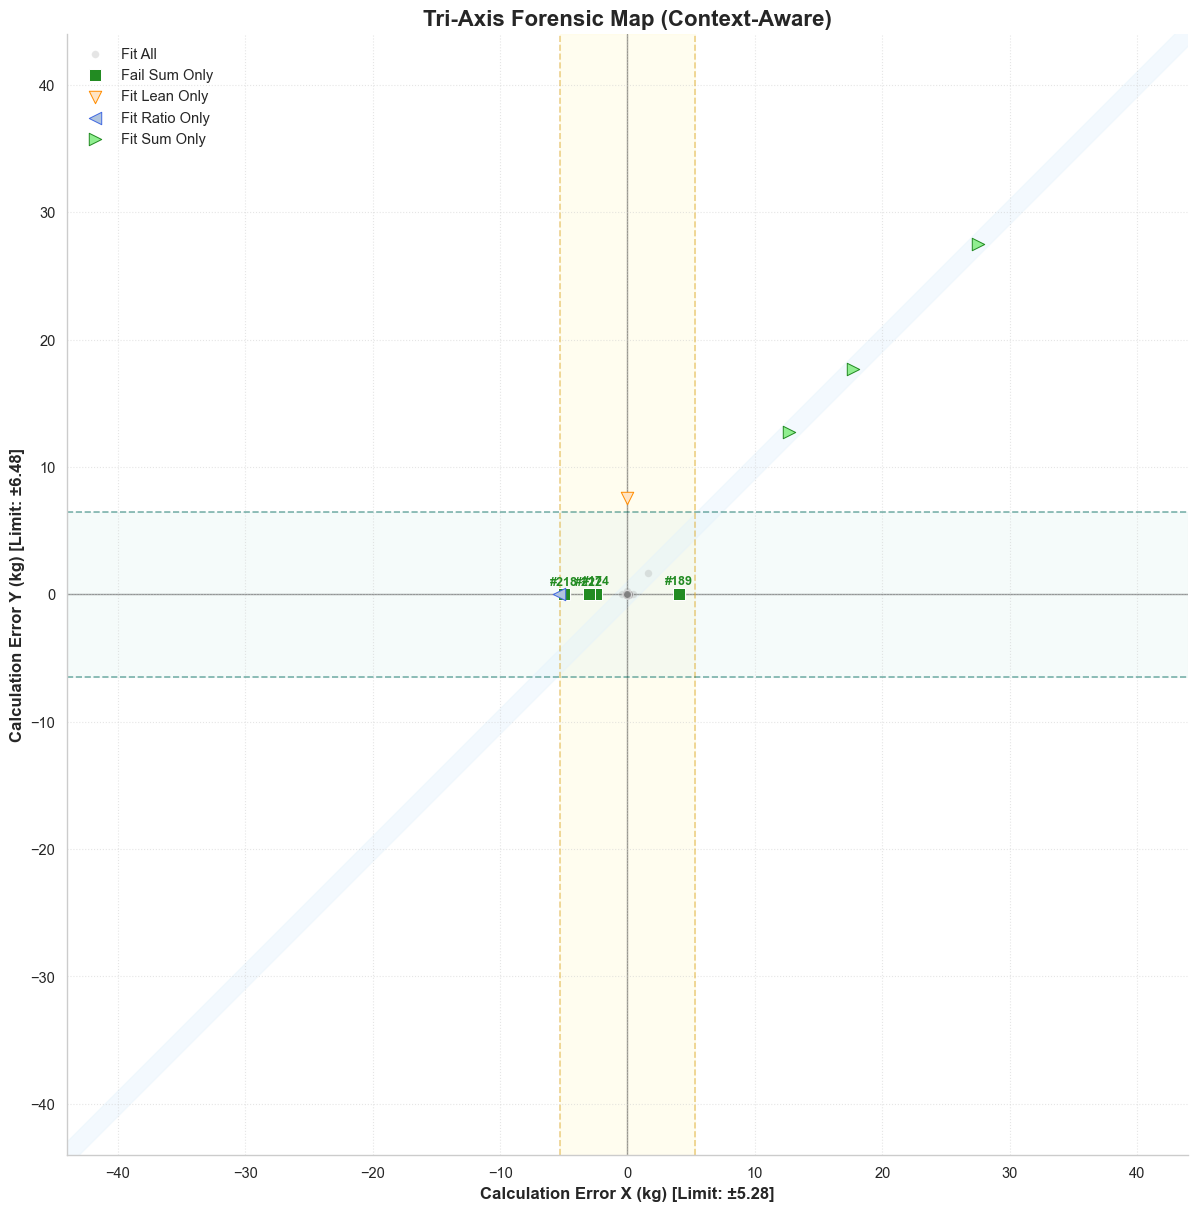

In [20]:
fig, ax = plt.subplots(figsize=(12, 12), constrained_layout=True)

# [LOGIC FIX]
# The plot range must be the LARGEST of:
# 1. The Data Deviations (Points)
# 2. The Sum Limits (Vertical Boundaries)
# 3. The Ratio Limits (Horizontal Boundaries)
# 4. A Minimum "Context" Range (e.g. 40) to prevent excessive zoom on perfect data
max_val = max(
    df_bioimpedance[col_TFC_disc_lean].abs().max(),      # Data X Max
    df_bioimpedance[col_TFC_disc_ratio].abs().max(),    # Data Y Max
    TFC_disc_lean_lim_val,                               # Limit X
    TFC_disc_ratio_lim_val,                             # Limit Y
    40                                                  # Min Visual Floor
) * 1.1 # Add 10% breathing room

# --- 2. DRAW ZONES (Background) ---

# A. Vertical (Sum Limit)
ax.axvspan(-TFC_disc_lean_lim_val, TFC_disc_lean_lim_val, color='#FFFACD', alpha=0.3, zorder=0)
ax.axvline(-TFC_disc_lean_lim_val, color='#DAA520', linestyle='--', alpha=0.5)
ax.axvline(TFC_disc_lean_lim_val, color='#DAA520', linestyle='--', alpha=0.5)

# B. Horizontal (Ratio Limit)
ax.axhspan(-TFC_disc_ratio_lim_val, TFC_disc_ratio_lim_val, color='#E0F2F1', alpha=0.3, zorder=0)
ax.axhline(-TFC_disc_ratio_lim_val, color='#00695C', linestyle='--', alpha=0.5)
ax.axhline(TFC_disc_ratio_lim_val, color='#00695C', linestyle='--', alpha=0.5)

# C. Diagonal (Consistency Rescue)
# [VISUAL FIX] Draw the diagonal 2x wider than the view to ensure it hits the corners
diag_x = np.linspace(-max_val * 2, max_val * 2, 100)
ax.fill_between(diag_x, diag_x - TFC_disc_sumOfRatio_lim_val, diag_x + TFC_disc_sumOfRatio_lim_val,
                color='#E3F2FD', alpha=0.4, zorder=0)

# --- 3. PLOT DATA WITH LABELS ---
def annotate_points(data_subset, color, y_offset=0):
    for i, row in data_subset.iterrows():
        ax.text(row[col_TFC_disc_lean], row[col_TFC_disc_ratio] + y_offset,
                f"#{row.name}",
                fontsize=9, fontweight='bold', color=color,
                ha='center', va='bottom', zorder=10)

# --- A. EXTREMES ---

# 1. Fit All (Background)
sns.scatterplot(data=df_bioimpedance[TFC_disc_fit_all_lim],
                x=col_TFC_disc_lean, y=col_TFC_disc_ratio,
                color='gray', alpha=0.2, s=30, label='Fit All', ax=ax, zorder=1)

# 2. Fail All (Critical)
data_fail_all = df_bioimpedance[TFC_disc_fail_all_lim]
sns.scatterplot(data=data_fail_all, x=col_TFC_disc_lean, y=col_TFC_disc_ratio,
                color='crimson', s=120, marker='X', edgecolor='white', label='Fail ALL', ax=ax, zorder=5)
annotate_points(data_fail_all, 'crimson', y_offset=1.0)


# --- B. SINGLE FAILURES (Almost Passed - Square Markers) ---

# 3. Fail Lean Only (Ratio & Sum passed)
data_fail_lean = df_bioimpedance[TFC_disc_fail_lean_only_lim]
sns.scatterplot(data=data_fail_lean, x=col_TFC_disc_lean, y=col_TFC_disc_ratio,
                color='darkorange', s=80, marker='s', label='Fail Lean Only', ax=ax, zorder=3)
annotate_points(data_fail_lean, 'darkorange', y_offset=0.5)

# 4. Fail Ratio Only (Lean & Sum passed)
data_fail_ratio = df_bioimpedance[TFC_disc_fail_ratio_only_lim]
sns.scatterplot(data=data_fail_ratio, x=col_TFC_disc_lean, y=col_TFC_disc_ratio,
                color='royalblue', s=80, marker='s', label='Fail Ratio Only', ax=ax, zorder=3)
annotate_points(data_fail_ratio, 'royalblue', y_offset=0.5)

# 5. Fail Sum Only (Lean & Ratio passed)
data_fail_sum = df_bioimpedance[TFC_disc_fail_sumOfRatio_only_lim]
sns.scatterplot(data=data_fail_sum, x=col_TFC_disc_lean, y=col_TFC_disc_ratio,
                color='forestgreen', s=80, marker='s', label='Fail Sum Only', ax=ax, zorder=3)
annotate_points(data_fail_sum, 'forestgreen', y_offset=0.5)


# --- C. DOUBLE FAILURES (Mostly Failed - Triangle Markers) ---

# 6. Fit Lean Only (Ratio & Sum failed)
data_fit_lean = df_bioimpedance[TFC_disc_fit_lean_only_lim]
sns.scatterplot(data=data_fit_lean, x=col_TFC_disc_lean, y=col_TFC_disc_ratio,
                color='bisque', s=80, marker='v', edgecolor='darkorange', label='Fit Lean Only', ax=ax, zorder=4)
# Optional: Annotate if critical
# annotate_points(data_fit_lean, 'darkorange')

# 7. Fit Ratio Only (Lean & Sum failed)
data_fit_ratio = df_bioimpedance[TFC_disc_fit_ratio_only_lim]
sns.scatterplot(data=data_fit_ratio, x=col_TFC_disc_lean, y=col_TFC_disc_ratio,
                color='lightsteelblue', s=80, marker='<', edgecolor='royalblue', label='Fit Ratio Only', ax=ax, zorder=4)

# 8. Fit Sum Only (Lean & Ratio failed)
data_fit_sum = df_bioimpedance[TFC_disc_fit_sumOfRatio_only_lim]
sns.scatterplot(data=data_fit_sum, x=col_TFC_disc_lean, y=col_TFC_disc_ratio,
                color='lightgreen', s=80, marker='>', edgecolor='forestgreen', label='Fit Sum Only', ax=ax, zorder=4)


# --- 4. FORMATTING ---
ax.set_aspect('equal')

# Explicitly set limits based on the new "Context-Aware" Max Value
ax.set_xlim(-max_val, max_val)
ax.set_ylim(-max_val, max_val)

ax.set_title("Tri-Axis Forensic Map (Context-Aware)", fontweight='bold', fontsize=16)
ax.set_xlabel(f"Calculation Error X (kg) [Limit: ±{TFC_disc_lean_lim_val:.2f}]")
ax.set_ylabel(f"Calculation Error Y (kg) [Limit: ±{TFC_disc_ratio_lim_val:.2f}]")

ax.legend(loc='upper left', framealpha=0.95)
ax.grid(True, linestyle=':', alpha=0.5)
ax.axhline(0, color='black', linewidth=1, alpha=0.4, zorder=0)
ax.axvline(0, color='black', linewidth=1, alpha=0.4, zorder=0)

plt.show()

In [21]:
# Fixing TFC column
col_TBFR_calc_ratio = 'TBFR_calc_ratio'
df_bioimpedance.loc[col_TBFR_calc_ratio] = df_bioimpedance['Total Fat Content (TFC)']/df_bioimpedance['Total Body Fat Ratio (TBFR) (%)'] * 100

col_TFC_fixed = 'TFC_fixed'
df_bioimpedance[col_TFC_fixed] = df_bioimpedance['Total Fat Content (TFC)']
col_TFC_fix_status = 'TFC_fixed_status'
df_bioimpedance[col_TFC_fix_status] = False

col_TBFR_fixed = 'TBFR_fixed'
df_bioimpedance[col_TBFR_fixed] = df_bioimpedance['Total Body Fat Ratio (TBFR) (%)']
col_TBFR_fix_status = 'TBFR_fixed_status'
df_bioimpedance[col_TBFR_fix_status] = False

col_LM_fixed = 'LM_fixed'
df_bioimpedance[col_LM_fixed] = df_bioimpedance['Lean Mass (LM) (%)']
col_LM_fix_status = 'LM_fixed_status'
df_bioimpedance[col_LM_fix_status] = False



# CASE 1: -> fit_sumOfRatio_only_lim -> Total Body Fat Content is wrong
df_bioimpedance.loc[TFC_disc_fail_sumOfRatio_only_lim, col_TFC_fixed] = df_bioimpedance.loc[TBW_disc_fail_ratio_lim, col_TFC_calc_ratio]
df_bioimpedance.loc[TFC_disc_fail_sumOfRatio_only_lim, col_TFC_fixed] = True

AssertionError: 